In [1]:
# import required packages
import numpy as np
import tensorflow as tf
from tensorflow import keras

import matplotlib.pyplot as plt

### Load and Explore Dataset

In [3]:
# load dataset
(X_train, y_train), (X_test, y_test) = keras.datasets.mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step


In [4]:
print('training data shape:', X_train.shape)
print('test data shape:', X_test.shape)

training data shape: (60000, 28, 28)
test data shape: (10000, 28, 28)


In [5]:
X_train[0]

array([[  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   3,
         18,  18,  18, 126, 136, 175,  26, 166, 255, 247, 127,   0,   0,
          0,   0],
       [  

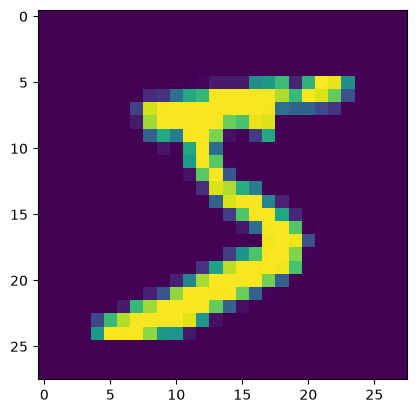

In [6]:
plt.imshow(X_train[0])

In [7]:
y_train[0]

np.uint8(5)

### Scale Data

In [8]:
X_train_scaled = X_train / 255
X_test_scaled = X_test / 255

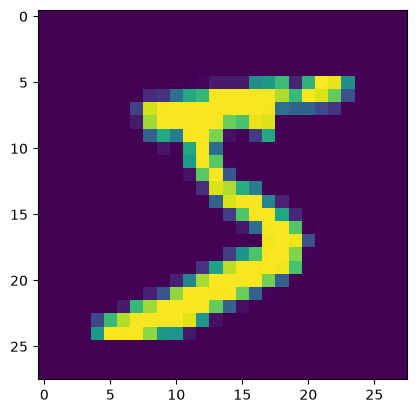

In [9]:
plt.imshow(X_train_scaled[0])

### Neural Network Training

In [10]:
# neural network creation
model = keras.Sequential([
    keras.layers.Flatten(input_shape=(28, 28)),
    keras.layers.Dense(50, activation='relu'),
    keras.layers.Dense(50, activation='relu'),
    keras.layers.Dense(10, activation='sigmoid')
])

c:\Users\ashut\OneDrive\Desktop\Rishikesh Paul\Projects\Digit-Detection\.venv\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [13]:
# neural network training
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.fit(
    X_train_scaled, y_train, epochs=7
)

Epoch 1/7
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 910us/step - accuracy: 0.9145 - loss: 0.2942
Epoch 2/7
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 873us/step - accuracy: 0.9584 - loss: 0.1376
Epoch 3/7
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 852us/step - accuracy: 0.9684 - loss: 0.1043
Epoch 4/7
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 867us/step - accuracy: 0.9745 - loss: 0.0830
Epoch 5/7
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 852us/step - accuracy: 0.9775 - loss: 0.0709
Epoch 6/7
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 863us/step - accuracy: 0.9808 - loss: 0.0599
Epoch 7/7
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 865us/step - accuracy: 0.9829 - loss: 0.0537


In [14]:
# model evaluation
model.evaluate(
    X_test_scaled, y_test
)

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 772us/step - accuracy: 0.9689 - loss: 0.1019


[0.1018875241279602, 0.9689000248908997]

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 654us/step


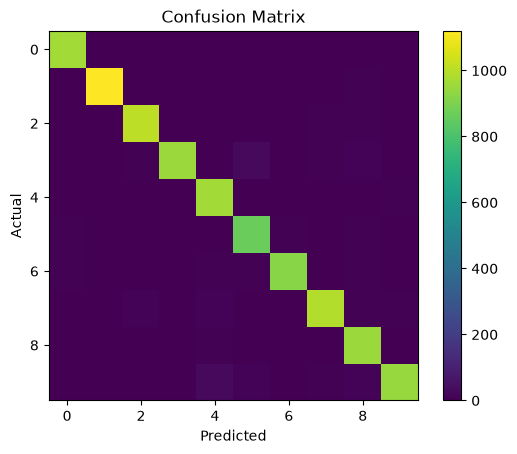

In [15]:
# cunfusion matrix for classification evaluation
y_pred = model.predict(X_test_scaled)
y_pred_labeled = [np.argmax(i) for i in y_pred]

cm = tf.math.confusion_matrix(
    labels=y_test,
    predictions=y_pred_labeled
)

plt.imshow(cm)
plt.colorbar()
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

### Model Testing

Test Sample:


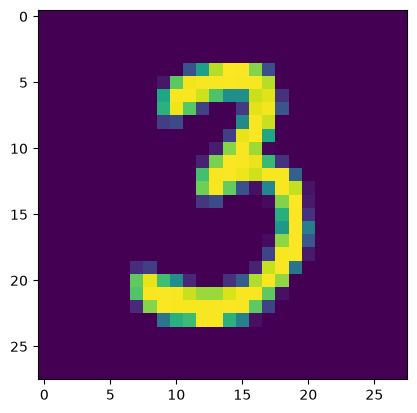

In [16]:
import random
n = random.randint(0, 10000)

test_sample = X_test[n]
print('Test Sample:')
plt.imshow(test_sample)

In [17]:
pred_arr = model.predict(test_sample[np.newaxis, :])
pred_num = np.argmax(pred_arr)

print('Model Prediction:', pred_num)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
Model Prediction: 3


### Save the Model

In [18]:
model.save("digit_detection_model.keras")